In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

In [10]:
df = pd.read_csv('../data/raw/creditcard.csv')

In [25]:
df['Hour'] = (df['Time'] // 3600) % 24

df['Day'] = (df['Time'] // (3600 * 24)) + 1

In [30]:
fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

In [12]:
df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,hour
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0.0


In [ ]:
print(f"Размер датасета: {df.shape}")
print(f"Фичи: {df.columns.tolist()}")

Размер датасета: (284807, 31)
Фичи: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [28]:
df['Amount'].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

In [33]:
class_counts = df['Class'].value_counts()
print(class_counts)

Class
0    284315
1       492
Name: count, dtype: int64


C:\Users\b1ur_fw\AppData\Local\Temp\ipykernel_5304\3970893972.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette=['green', 'red'])


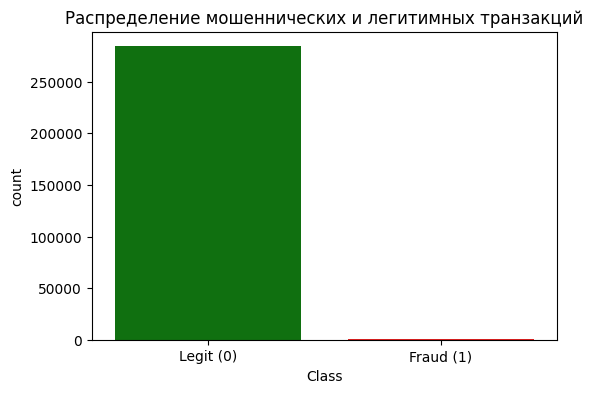

In [51]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df, palette=['green', 'red'])
plt.title('Распределение мошеннических и легитимных транзакций')
plt.xticks([0, 1], ['Legit (0)', 'Fraud (1)'])
plt.show()

In [35]:
print(f"Процент мошеннических транзакций: {class_counts[1] / len(df) * 100:.3f}%")

Процент мошеннических транзакций: 0.173%


In [28]:
print("\n" + "="*50)
print("СРАВНЕНИЕ ПРИЗНАКОВ V (Fraud vs Legit):")
print("="*50)
# Сравним средние значения для примера (первые 4 признака V)
print("Средние значения V1-V4 для мошеннических транзакций:")
print(fraud[['V1', 'V2', 'V3', 'V4']].mean())
print("\nСредние значения V1-V4 для легитимных транзакций:")
print(legit[['V1', 'V2', 'V3', 'V4']].mean())



СРАВНЕНИЕ ПРИЗНАКОВ V (Fraud vs Legit):
Средние значения V1-V4 для мошеннических транзакций:
V1   -4.771948
V2    3.623778
V3   -7.033281
V4    4.542029
dtype: float64

Средние значения V1-V4 для легитимных транзакций:
V1    0.008258
V2   -0.006271
V3    0.012171
V4   -0.007860
dtype: float64


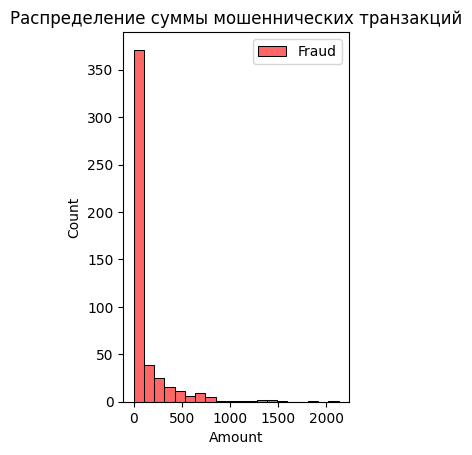

In [53]:
plt.subplot(1, 2, 2)
plt.title('Распределение суммы мошеннических транзакций')
sns.histplot(fraud['Amount'], bins=20, color='red', label='Fraud', alpha=0.6)
plt.legend()

In [41]:
fraud['Amount'].describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

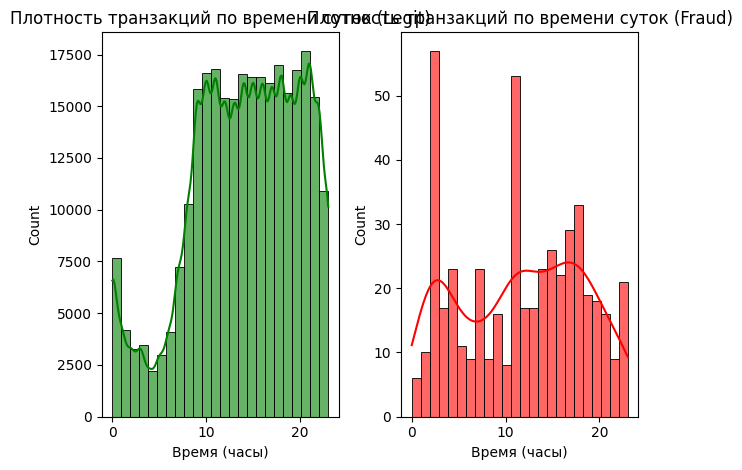

In [55]:
plt.subplot(1, 2, 1)
plt.title('Плотность транзакций по времени суток (Legit)')
sns.histplot(legit['hour'], bins=24, color='green', alpha=0.6, kde=True) # 48 баров = 30 минут
plt.xlabel('Время (часы)')

plt.subplot(1, 2, 2)
plt.title('Плотность транзакций по времени суток (Fraud)')
sns.histplot(fraud['hour'], bins=24, color='red', alpha=0.6, kde=True)
plt.xlabel('Время (часы)')

plt.tight_layout()
plt.show()

In [56]:
df['hour']

0          0.0
1          0.0
2          0.0
3          0.0
4          0.0
          ... 
284802    23.0
284803    23.0
284804    23.0
284805    23.0
284806    23.0
Name: hour, Length: 284807, dtype: float64

In [58]:
corr_with_class = df.corr()['Class'].sort_values(ascending=False)
print("\n" + "="*50)
print("ТОП-5 ПРИЗНАКОВ, КОРРЕЛИРУЮЩИХ С CLASS:")
print("="*50)
print(corr_with_class.head(10))



ТОП-5 ПРИЗНАКОВ, КОРРЕЛИРУЮЩИХ С CLASS:
Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
V20      0.020090
V8       0.019875
V27      0.017580
V28      0.009536
Name: Class, dtype: float64


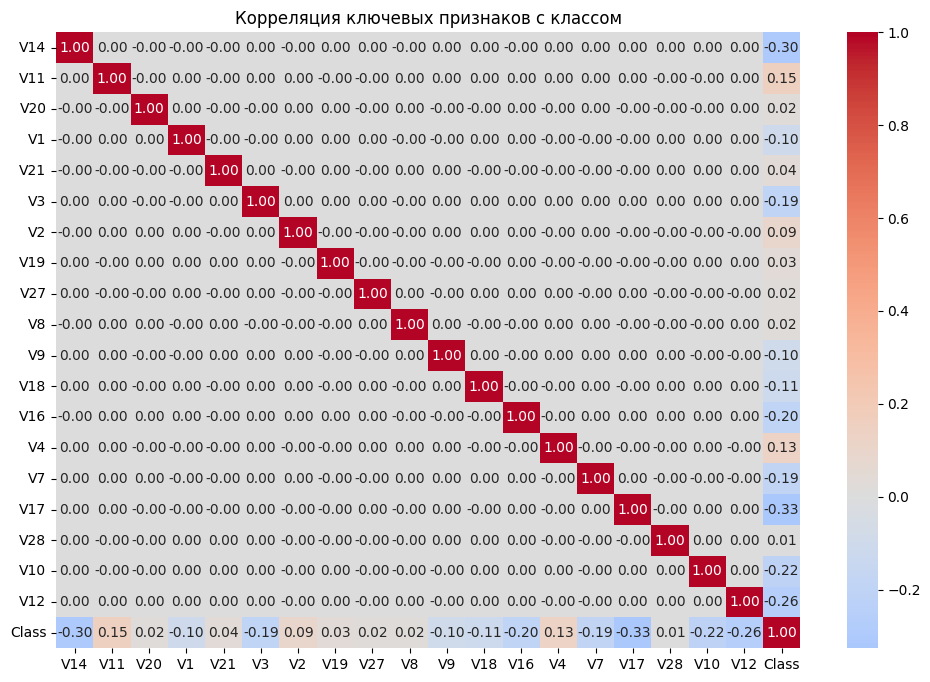

In [59]:
top_features = corr_with_class.head(10).index.tolist() + corr_with_class.tail(10).index.tolist()
# Убираем дубликаты (если класс попал дважды)
top_features = list(set(top_features))
top_features.remove('Class') # Убираем саму целевую переменную

plt.figure(figsize=(12, 8))
sns.heatmap(df[top_features + ['Class']].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляция ключевых признаков с классом')
plt.show()

In [6]:
fig1 = plt.figure(1, figsize=(20, 16))
fig1.suptitle('Credit Card Fraud Detection: Анализ данных', fontsize=24, fontweight='bold', y=0.98)

gs = GridSpec(4, 3, figure=fig1, hspace=0.3, wspace=0.3)

<Figure size 2000x1600 with 0 Axes>

C:\Users\b1ur_fw\AppData\Local\Temp\ipykernel_15192\4021569841.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Amount', data=df_box, ax=ax7, palette=['#2ecc71', '#e74c3c'])
C:\Users\b1ur_fw\AppData\Local\Temp\ipykernel_15192\4021569841.py:99: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax7.set_xticklabels(['Legit', 'Fraud'])
C:\Users\b1ur_fw\AppData\Local\Temp\ipykernel_15192\4021569841.py:140: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


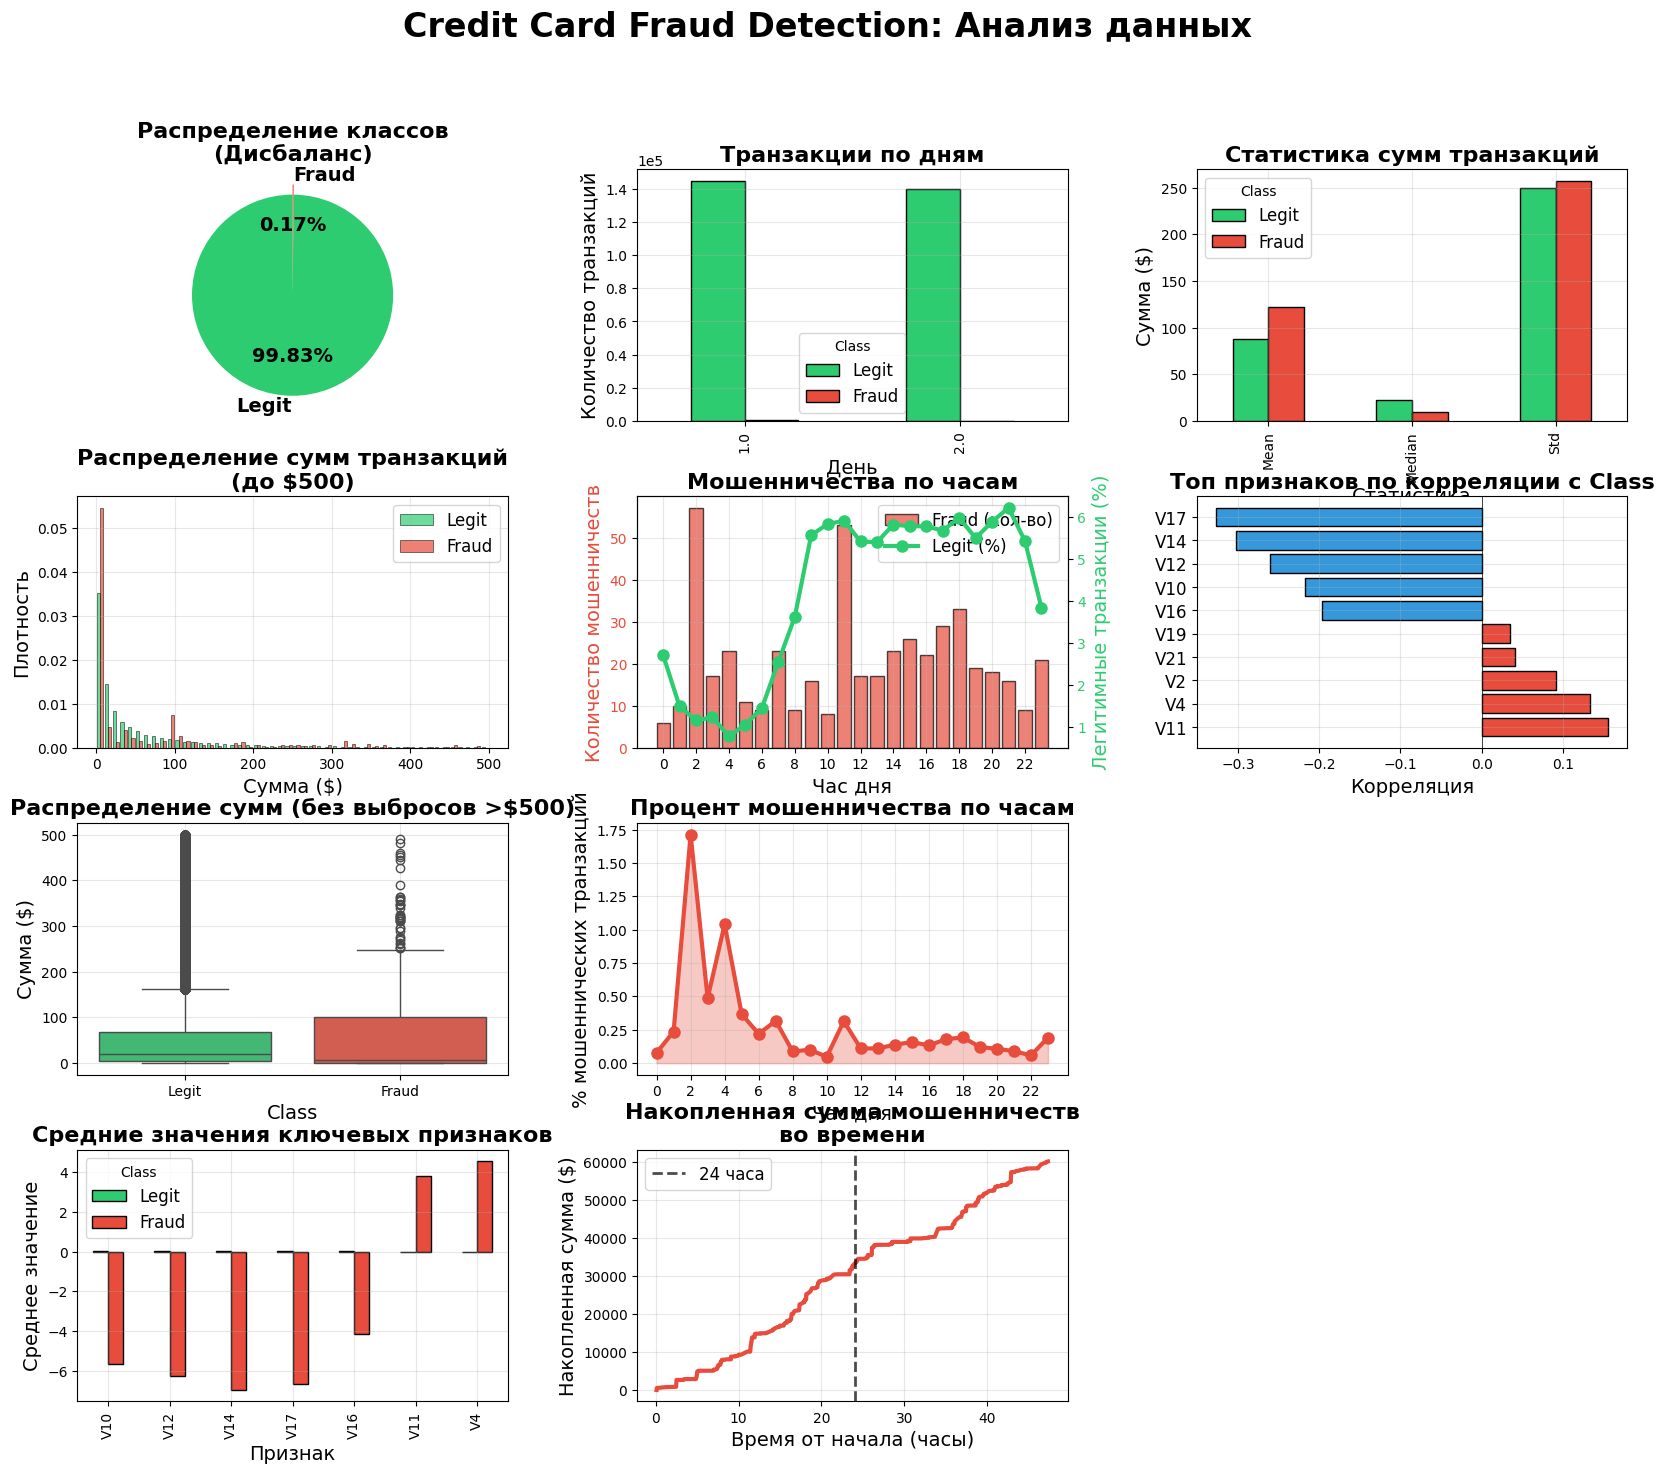

In [45]:

# =======================================================================
# 1. ДАШБОРД С ОСНОВНОЙ ИНФОРМАЦИЕЙ
# =======================================================================
fig1 = plt.figure(1, figsize=(20, 16))
fig1.suptitle('Credit Card Fraud Detection: Анализ данных', fontsize=24, fontweight='bold', y=0.98)

gs = GridSpec(4, 3, figure=fig1, hspace=0.3, wspace=0.3)

# 1.1 Pie chart классов
ax1 = fig1.add_subplot(gs[0, 0])
colors = ['#2ecc71', '#e74c3c']
sizes = [len(legit), len(fraud)]
explode = (0, 0.1)
wedges, texts, autotexts = ax1.pie(sizes, explode=explode, labels=['Legit', 'Fraud'], 
                                    colors=colors, autopct='%1.2f%%', startangle=90,
                                    textprops={'fontsize': 14, 'fontweight': 'bold'})
ax1.set_title('Распределение классов\n(Дисбаланс)', fontsize=16, fontweight='bold')

# 1.2 Количество транзакций по дням
ax2 = fig1.add_subplot(gs[0, 1])
day_counts = df.groupby(['Day', 'Class']).size().unstack()
day_counts.columns = ['Legit', 'Fraud']
day_counts.plot(kind='bar', ax=ax2, color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=1)
ax2.set_title('Транзакции по дням', fontsize=16, fontweight='bold')
ax2.set_xlabel('День', fontsize=14)
ax2.set_ylabel('Количество транзакций', fontsize=14)
ax2.legend(title='Class', fontsize=12)
ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax2.grid(True, alpha=0.3)

# 1.3 Статистика сумм
ax3 = fig1.add_subplot(gs[0, 2])
amount_stats = pd.DataFrame({
    'Legit': [legit['Amount'].mean(), legit['Amount'].median(), legit['Amount'].std()],
    'Fraud': [fraud['Amount'].mean(), fraud['Amount'].median(), fraud['Amount'].std()]
}, index=['Mean', 'Median', 'Std'])
amount_stats.plot(kind='bar', ax=ax3, color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=1)
ax3.set_title('Статистика сумм транзакций', fontsize=16, fontweight='bold')
ax3.set_xlabel('Статистика', fontsize=14)
ax3.set_ylabel('Сумма ($)', fontsize=14)
ax3.legend(title='Class', fontsize=12)
ax3.grid(True, alpha=0.3)

# 1.4 Распределение сумм (гистограмма)
ax4 = fig1.add_subplot(gs[1, 0])
ax4.hist([legit['Amount'], fraud['Amount']], bins=50, range=(0, 500), 
         color=['#2ecc71', '#e74c3c'], alpha=0.7, label=['Legit', 'Fraud'], density=True, 
         edgecolor='black', linewidth=0.5)
ax4.set_title('Распределение сумм транзакций\n(до $500)', fontsize=16, fontweight='bold')
ax4.set_xlabel('Сумма ($)', fontsize=14)
ax4.set_ylabel('Плотность', fontsize=14)
ax4.legend(fontsize=12)
ax4.grid(True, alpha=0.3)

# 1.5 Мошенничества по часам
ax5 = fig1.add_subplot(gs[1, 1])
fraud_by_hour = fraud['Hour'].value_counts().sort_index()
legit_by_hour = legit['Hour'].value_counts().sort_index() / len(legit) * 100

ax5.bar(fraud_by_hour.index, fraud_by_hour.values, color='#e74c3c', alpha=0.7, 
        edgecolor='black', linewidth=1, label='Fraud (кол-во)')
ax5.set_title('Мошенничества по часам', fontsize=16, fontweight='bold')
ax5.set_xlabel('Час дня', fontsize=14)
ax5.set_ylabel('Количество мошенничеств', fontsize=14, color='#e74c3c')
ax5.set_xticks(range(0, 24, 2))
ax5.tick_params(axis='y', labelcolor='#e74c3c')
ax5.grid(True, alpha=0.3)

ax5_twin = ax5.twinx()
ax5_twin.plot(legit_by_hour.index, legit_by_hour.values, color='#2ecc71', linewidth=3, 
              marker='o', markersize=8, label='Legit (%)')
ax5_twin.set_ylabel('Легитимные транзакции (%)', fontsize=14, color='#2ecc71')
ax5_twin.tick_params(axis='y', labelcolor='#2ecc71')

lines1, labels1 = ax5.get_legend_handles_labels()
lines2, labels2 = ax5_twin.get_legend_handles_labels()
ax5.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=12)

# 1.6 Топ-10 признаков по корреляции
ax6 = fig1.add_subplot(gs[1, 2])
corr_with_class = df.corr()['Class'].sort_values(ascending=False)
top_corr = pd.concat([corr_with_class.head(6)[1:], corr_with_class.tail(5)])
colors_corr = ['#e74c3c' if x > 0 else '#3498db' for x in top_corr.values]
ax6.barh(range(len(top_corr)), top_corr.values, color=colors_corr, edgecolor='black', linewidth=1)
ax6.set_yticks(range(len(top_corr)))
ax6.set_yticklabels(top_corr.index, fontsize=12)
ax6.set_title('Топ признаков по корреляции с Class', fontsize=16, fontweight='bold')
ax6.set_xlabel('Корреляция', fontsize=14)
ax6.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax6.grid(True, alpha=0.3)

# 1.7 Boxplot сумм
ax7 = fig1.add_subplot(gs[2, 0])
df_box = df[df['Amount'] < 500]
sns.boxplot(x='Class', y='Amount', data=df_box, ax=ax7, palette=['#2ecc71', '#e74c3c'])
ax7.set_title('Распределение сумм (без выбросов >$500)', fontsize=16, fontweight='bold')
ax7.set_xlabel('Class', fontsize=14)
ax7.set_ylabel('Сумма ($)', fontsize=14)
ax7.set_xticklabels(['Legit', 'Fraud'])
ax7.grid(True, alpha=0.3)

# 1.8 Процент мошенничества по часам
ax8 = fig1.add_subplot(gs[2, 1])
fraud_rate_by_hour = (fraud_by_hour / df.groupby('Hour').size()) * 100
ax8.plot(fraud_rate_by_hour.index, fraud_rate_by_hour.values, marker='o', 
         color='#e74c3c', linewidth=3, markersize=8)
ax8.fill_between(fraud_rate_by_hour.index, fraud_rate_by_hour.values, alpha=0.3, color='#e74c3c')
ax8.set_title('Процент мошенничества по часам', fontsize=16, fontweight='bold')
ax8.set_xlabel('Час дня', fontsize=14)
ax8.set_ylabel('% мошеннических транзакций', fontsize=14)
ax8.set_xticks(range(0, 24, 2))
ax8.grid(True, alpha=0.3)

# 1.10 Сравнение средних значений ключевых признаков
ax10 = fig1.add_subplot(gs[3, 0])
key_features = ['V10', 'V12', 'V14', 'V17', 'V16', 'V11', 'V4']
feature_means = pd.DataFrame({
    'Legit': [legit[f].mean() for f in key_features],
    'Fraud': [fraud[f].mean() for f in key_features]
}, index=key_features)
feature_means.plot(kind='bar', ax=ax10, color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=1)
ax10.set_title('Средние значения ключевых признаков', fontsize=16, fontweight='bold')
ax10.set_xlabel('Признак', fontsize=14)
ax10.set_ylabel('Среднее значение', fontsize=14)
ax10.legend(title='Class', fontsize=12)
ax10.grid(True, alpha=0.3)

# 1.11 Cumulative суммы мошенничеств
ax11 = fig1.add_subplot(gs[3, 1])
fraud_sorted = fraud.sort_values('Time')
cumulative_fraud = fraud_sorted['Amount'].cumsum()
ax11.plot(fraud_sorted['Time'] / 3600, cumulative_fraud, color='#e74c3c', linewidth=3)
ax11.set_title('Накопленная сумма мошенничеств\nво времени', fontsize=16, fontweight='bold')
ax11.set_xlabel('Время от начала (часы)', fontsize=14)
ax11.set_ylabel('Накопленная сумма ($)', fontsize=14)
ax11.axvline(x=24, color='black', linestyle='--', alpha=0.7, linewidth=2, label='24 часа')
ax11.legend(fontsize=12)
ax11.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

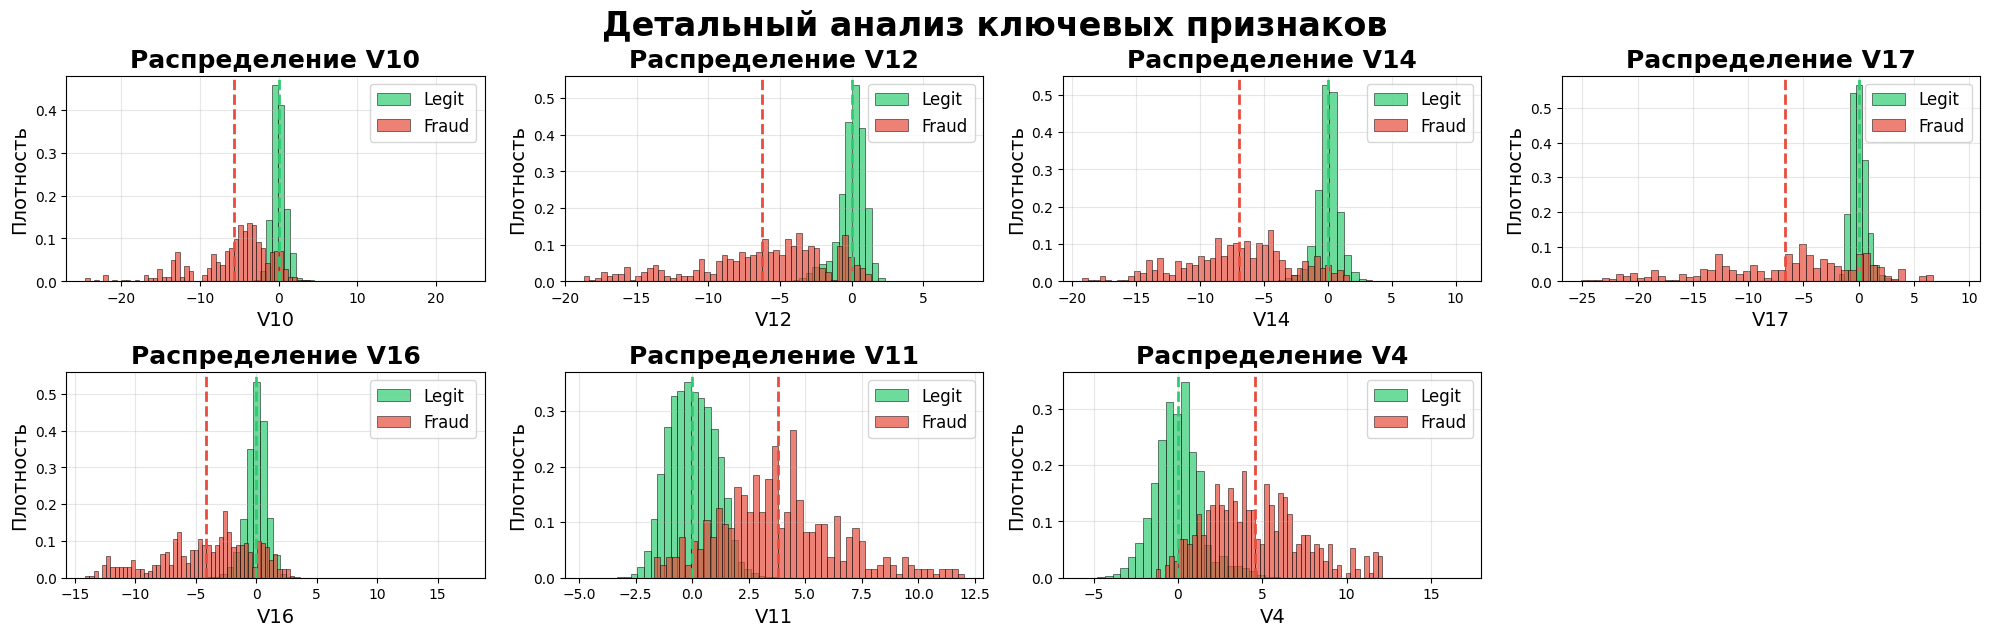

In [47]:
# =======================================================================
# 2. ДЕТАЛЬНЫЙ АНАЛИЗ КЛЮЧЕВЫХ ПРИЗНАКОВ
# =======================================================================
fig2 = plt.figure(2, figsize=(20, 12))
fig2.suptitle('Детальный анализ ключевых признаков', fontsize=24, fontweight='bold', y=0.98)

for i, feature in enumerate(key_features, 1):
    ax = fig2.add_subplot(4, 4, i)
    
    # Гистограммы
    ax.hist(legit[feature], bins=50, alpha=0.7, color='#2ecc71', 
            label='Legit', density=True, edgecolor='black', linewidth=0.5)
    ax.hist(fraud[feature], bins=50, alpha=0.7, color='#e74c3c', 
            label='Fraud', density=True, edgecolor='black', linewidth=0.5)
    
    ax.set_title(f'Распределение {feature}', fontsize=18, fontweight='bold')
    ax.set_xlabel(feature, fontsize=14)
    ax.set_ylabel('Плотность', fontsize=14)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # Добавим вертикальные линии для средних
    ax.axvline(legit[feature].mean(), color='#2ecc71', linestyle='--', linewidth=2, 
               label=f'Legit mean: {legit[feature].mean():.2f}')
    ax.axvline(fraud[feature].mean(), color='#e74c3c', linestyle='--', linewidth=2, 
               label=f'Fraud mean: {fraud[feature].mean():.2f}')

plt.tight_layout()
plt.show()

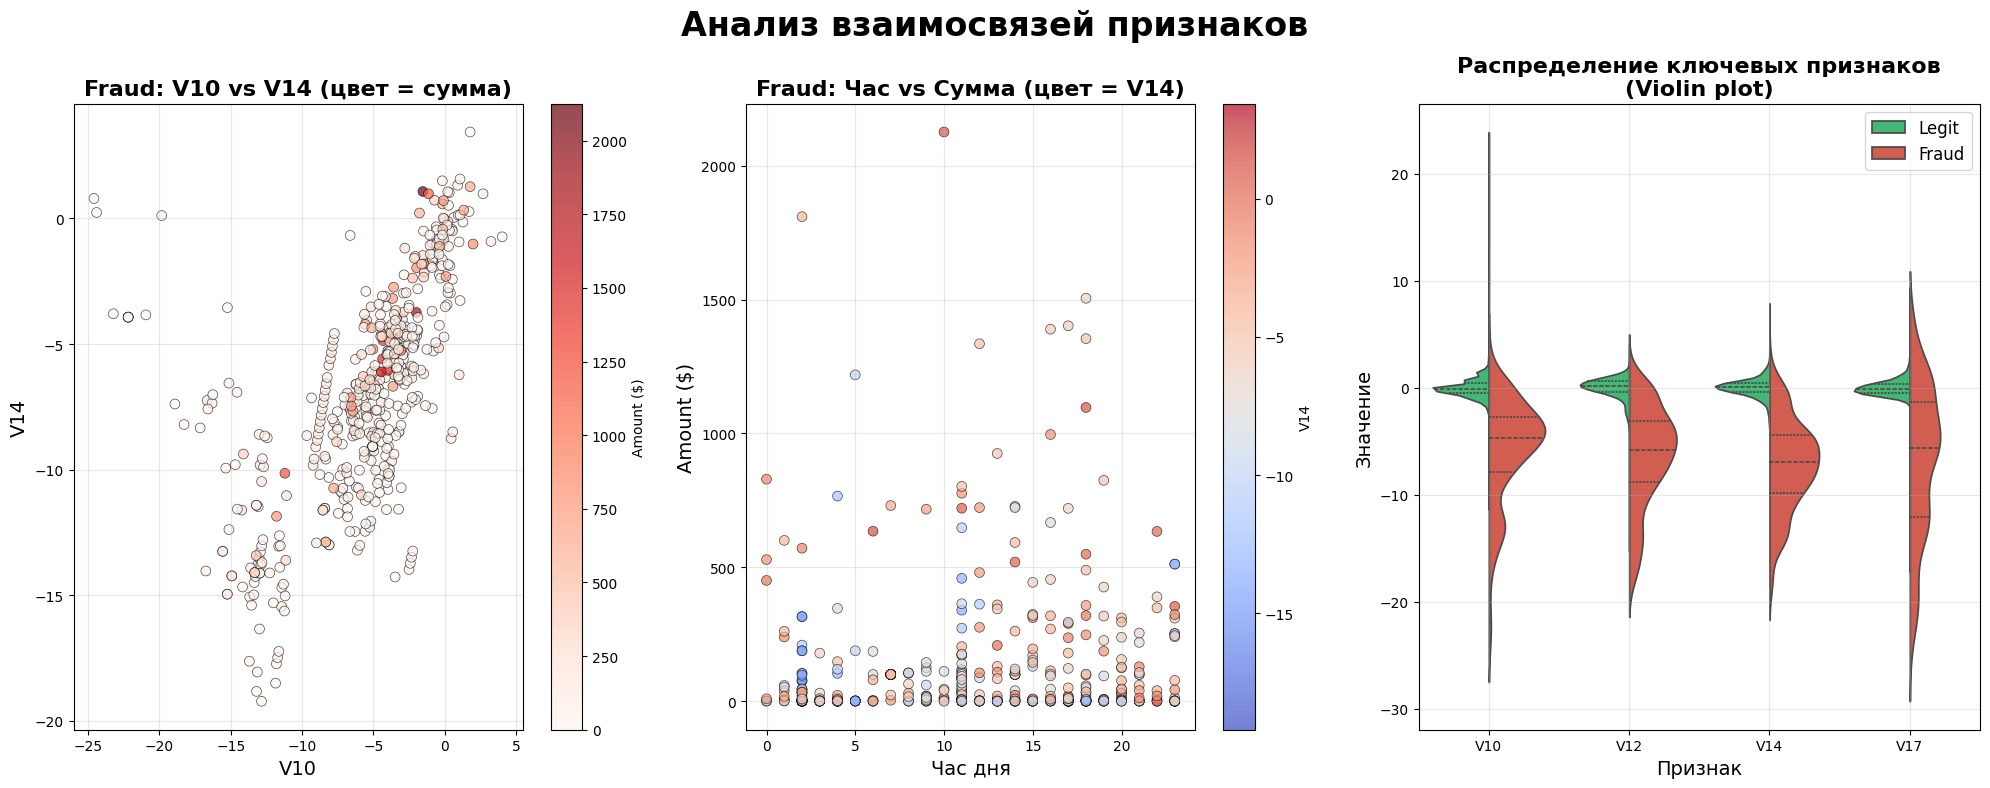

In [35]:
# =======================================================================
# 3. АНАЛИЗ ВЗАИМОСВЯЗЕЙ
# =======================================================================
fig3 = plt.figure(3, figsize=(20, 8))
fig3.suptitle('Анализ взаимосвязей признаков', fontsize=24, fontweight='bold', y=0.98)

# 3.1 Scatter plot для двух ключевых признаков
ax1 = fig3.add_subplot(1, 3, 1)
scatter = ax1.scatter(fraud['V10'], fraud['V14'], c=fraud['Amount'], 
                      cmap='Reds', s=50, alpha=0.7, edgecolor='black', linewidth=0.5)
ax1.set_xlabel('V10', fontsize=14)
ax1.set_ylabel('V14', fontsize=14)
ax1.set_title('Fraud: V10 vs V14 (цвет = сумма)', fontsize=16, fontweight='bold')
plt.colorbar(scatter, ax=ax1, label='Amount ($)')
ax1.grid(True, alpha=0.3)

# 3.2 Amount vs Hour для fraud
ax2 = fig3.add_subplot(1, 3, 2)
scatter2 = ax2.scatter(fraud['Hour'], fraud['Amount'], c=fraud['V14'], 
                       cmap='coolwarm', s=50, alpha=0.7, edgecolor='black', linewidth=0.5)
ax2.set_xlabel('Час дня', fontsize=14)
ax2.set_ylabel('Amount ($)', fontsize=14)
ax2.set_title('Fraud: Час vs Сумма (цвет = V14)', fontsize=16, fontweight='bold')
plt.colorbar(scatter2, ax=ax2, label='V14')
ax2.grid(True, alpha=0.3)

# 3.3 Violin plot для ключевых признаков
ax3 = fig3.add_subplot(1, 3, 3)
df_melted = pd.melt(df[df['Amount'] < 500], id_vars=['Class'], value_vars=['V10', 'V12', 'V14', 'V17'])
df_melted['Class'] = df_melted['Class'].map({0: 'Legit', 1: 'Fraud'})
sns.violinplot(data=df_melted, x='variable', y='value', hue='Class', 
               split=True, inner='quart', palette=['#2ecc71', '#e74c3c'], ax=ax3)
ax3.set_title('Распределение ключевых признаков\n(Violin plot)', fontsize=16, fontweight='bold')
ax3.set_xlabel('Признак', fontsize=14)
ax3.set_ylabel('Значение', fontsize=14)
ax3.legend(fontsize=12)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [44]:
# =======================================================================
# 4. ОТЧЕТ
# =======================================================================
print("="*80)
print("СТАТИСТИЧЕСКИЙ ОТЧЕТ ПО ДАННЫМ".center(80))
print("="*80)

print(f"\n ОБЩАЯ ИНФОРМАЦИЯ:")
print(f"   - Всего транзакций: {len(df):,}")
print(f"   - Период сбора: {df['Time'].max()/3600:.1f} часов ({df['Day'].max()} дня)")
print(f"   - Признаков: {df.shape[1] - 5} (V1-V28 + Time + Amount)")

print(f"\n МОШЕННИЧЕСТВО (FRAUD):")
print(f"   - Количество случаев: {len(fraud)}")
print(f"   - Процент от всех: {len(fraud)/len(df)*100:.3f}%")
print(f"   - Средняя сумма: ${fraud['Amount'].mean():.2f}")
print(f"   - Медианная сумма: ${fraud['Amount'].median():.2f}")
print(f"   - Стандартное отклонение: ${fraud['Amount'].std():.2f}")
print(f"   - Минимальная сумма: ${fraud['Amount'].min():.2f}")
print(f"   - Максимальная сумма: ${fraud['Amount'].max():.2f}")

print(f"\n ЛЕГИТИМНЫЕ (LEGIT):")
print(f"   - Количество случаев: {len(legit):,}")
print(f"   - Процент от всех: {len(legit)/len(df)*100:.3f}%")
print(f"   - Средняя сумма: ${legit['Amount'].mean():.2f}")
print(f"   - Медианная сумма: ${legit['Amount'].median():.2f}")
print(f"   - Стандартное отклонение: ${legit['Amount'].std():.2f}")

print(f"\n ВРЕМЕННОЙ АНАЛИЗ:")
print(f"   - Час с наибольшим кол-вом мошенничеств: {fraud_by_hour.idxmax()}:00 ({fraud_by_hour.max()} случаев)")
print(f"   - Час с наименьшим кол-вом мошенничеств: {fraud_by_hour.idxmin()}:00 ({fraud_by_hour.min()} случаев)")
print(f"   - Мошенничеств в 1й день: {len(fraud[fraud['Day']==1])}")
print(f"   - Мошенничеств во 2й день: {len(fraud[fraud['Day']==2])}")

print(f"\n ТОП-5 ПРИЗНАКОВ ПО КОРРЕЛЯЦИИ С FRAUD:")
for feat, corr in corr_with_class.head(6)[1:].items():
    print(f"   - {feat}: {corr:.3f}")

print(f"\nТОП-5 ПРИЗНАКОВ С ОТРИЦАТЕЛЬНОЙ КОРРЕЛЯЦИЕЙ:")
for feat, corr in corr_with_class.tail(5).items():
    print(f"   - {feat}: {corr:.3f}")


                         СТАТИСТИЧЕСКИЙ ОТЧЕТ ПО ДАННЫМ                         

 ОБЩАЯ ИНФОРМАЦИЯ:
   - Всего транзакций: 284,807
   - Период сбора: 48.0 часов (2.0 дня)
   - Признаков: 29 (V1-V28 + Time + Amount)

 МОШЕННИЧЕСТВО (FRAUD):
   - Количество случаев: 492
   - Процент от всех: 0.173%
   - Средняя сумма: $122.21
   - Медианная сумма: $9.25
   - Стандартное отклонение: $256.68
   - Минимальная сумма: $0.00
   - Максимальная сумма: $2125.87

 ЛЕГИТИМНЫЕ (LEGIT):
   - Количество случаев: 284,315
   - Процент от всех: 99.827%
   - Средняя сумма: $88.29
   - Медианная сумма: $22.00
   - Стандартное отклонение: $250.11

 ВРЕМЕННОЙ АНАЛИЗ:
   - Час с наибольшим кол-вом мошенничеств: 2.0:00 (57 случаев)
   - Час с наименьшим кол-вом мошенничеств: 0.0:00 (6 случаев)
   - Мошенничеств в 1й день: 281
   - Мошенничеств во 2й день: 211

 ТОП-5 ПРИЗНАКОВ ПО КОРРЕЛЯЦИИ С FRAUD:
   - V11: 0.155
   - V4: 0.133
   - V2: 0.091
   - V21: 0.040
   - V19: 0.035

ТОП-5 ПРИЗНАКОВ С ОТРИЦАТЕЛЬНОЙ 